<a href="https://colab.research.google.com/github/PromitMukherjee/Machine_learning_Algorithm/blob/main/Unsupervised_Learning/K-Mean-Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Unsupervised Learning: K-Mean-Clustering
# ============================================================
# LARGE SYNTHETIC DATASET GENERATION
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

N = 100_000          # Number of samples
D = 4                # Number of features
K = 5                # Number of clusters
RANDOM_SEED = 42

rng = np.random.default_rng(RANDOM_SEED)

# ------------------------------------------------------------
# Cluster configuration
# ------------------------------------------------------------

# Well-separated centers in 4-dimensional space.
cluster_centers = np.array([
    [-8.0, -5.0,  0.0,  2.0],
    [-2.0,  6.0,  5.0, -3.0],
    [ 5.0, -4.0,  7.0,  4.0],
    [ 9.0,  7.0, -5.0, -2.0],
    [ 1.0,  1.0, -7.0,  8.0]
], dtype=np.float64)

# Samples per cluster
samples_per_cluster = N // K

X_parts = []
y_parts = []

for cluster_id in range(K):

    # Slightly different spread for each cluster
    scale = 1.0 + 0.15 * cluster_id

    X_cluster = (
        cluster_centers[cluster_id]
        + rng.normal(
            loc=0.0,
            scale=scale,
            size=(samples_per_cluster, D)
        )
    )

    y_cluster = np.full(
        samples_per_cluster,
        cluster_id,
        dtype=np.int64
    )

    X_parts.append(X_cluster)
    y_parts.append(y_cluster)

# Combine
X = np.vstack(X_parts)
y_true = np.concatenate(y_parts)

# ------------------------------------------------------------
# Shuffle the complete dataset once.
# The resulting X and y_true are reused by EVERY algorithm.
# ------------------------------------------------------------

shuffle_indices = rng.permutation(N)

X = X[shuffle_indices]
y_true = y_true[shuffle_indices]

# ------------------------------------------------------------
# Output
# ------------------------------------------------------------

print("=" * 70)
print("DATASET SUMMARY")
print("=" * 70)

print("X shape       :", X.shape)
print("y_true shape  :", y_true.shape)
print("Samples (N)   :", N)
print("Features (D)  :", D)
print("Clusters (K)  :", K)

print("\nFeature Summary:")
print(
    pd.DataFrame(X, columns=[f"Feature_{i+1}" for i in range(D)])
    .describe()
    .round(4)
)

print("\nGround Truth Cluster Counts:")
print(
    pd.Series(y_true)
    .value_counts()
    .sort_index()
    .rename("Count")
)

print("\nGround Truth Cluster Centers:")
print(cluster_centers)

DATASET SUMMARY
X shape       : (100000, 4)
y_true shape  : (100000,)
Samples (N)   : 100000
Features (D)  : 4
Clusters (K)  : 5

Feature Summary:
         Feature_1    Feature_2    Feature_3    Feature_4
count  100000.0000  100000.0000  100000.0000  100000.0000
mean        1.0018       1.0075      -0.0039       1.7959
std         5.9743       5.1060       5.5942       4.2353
min       -11.5304      -8.9068     -13.2584      -7.6210
25%        -2.7939      -4.1390      -5.3649      -2.1193
50%         1.0185       1.0276      -0.0207       1.8841
75%         5.8138       6.0012       5.4052       4.8045
max        15.7759      12.3418      13.3846      14.6308

Ground Truth Cluster Counts:
0    20000
1    20000
2    20000
3    20000
4    20000
Name: Count, dtype: int64

Ground Truth Cluster Centers:
[[-8. -5.  0.  2.]
 [-2.  6.  5. -3.]
 [ 5. -4.  7.  4.]
 [ 9.  7. -5. -2.]
 [ 1.  1. -7.  8.]]


In [2]:
# ============================================================
# CUSTOM CLUSTER EVALUATION METRICS
# ============================================================

import numpy as np


# ============================================================
# 1. SILHOUETTE SCORE
# ============================================================

def silhouette_score_from_scratch(
    X,
    labels,
    sample_size=500,
    random_state=42
):
    """
    Silhouette Score from scratch.

    For each evaluated point i:

        a(i) = mean distance from i to points
               in its own cluster

        b(i) = minimum mean distance from i to
               points in another cluster

        s(i) = (b(i) - a(i)) / max(a(i), b(i))

    Because N=100,000, evaluating every point exactly would
    require O(N^2) pairwise distances.

    Therefore:
        - selected points are deterministic
        - distances are calculated against ALL N points
        - the resulting score is the mean silhouette of
          those evaluated points.
    """

    rng = np.random.default_rng(random_state)

    n = X.shape[0]

    if sample_size is None or sample_size >= n:
        sample_indices = np.arange(n)
    else:
        sample_indices = rng.choice(
            n,
            size=sample_size,
            replace=False
        )

    X_eval = X[sample_indices]
    labels_eval = labels[sample_indices]

    unique_labels = np.unique(labels)

    # Accumulate silhouette values
    silhouette_values = np.zeros(len(sample_indices))

    for i in range(len(sample_indices)):

        x_i = X_eval[i]
        own_cluster = labels_eval[i]

        # ----------------------------------------------------
        # Euclidean distance from x_i to every data point
        #
        # ||x-y|| = sqrt(sum((x-y)^2))
        # ----------------------------------------------------

        distances = np.sqrt(
            np.sum(
                (X - x_i) ** 2,
                axis=1
            )
        )

        # ----------------------------------------------------
        # a(i): mean intra-cluster distance
        # Exclude the point itself.
        # ----------------------------------------------------

        own_mask = (labels == own_cluster)
        own_mask[sample_indices[i]] = False

        if np.any(own_mask):
            a_i = np.mean(distances[own_mask])
        else:
            a_i = 0.0

        # ----------------------------------------------------
        # b(i): nearest mean distance to another cluster
        # ----------------------------------------------------

        b_i = np.inf

        for cluster_id in unique_labels:

            if cluster_id == own_cluster:
                continue

            other_mask = (labels == cluster_id)

            mean_distance = np.mean(
                distances[other_mask]
            )

            if mean_distance < b_i:
                b_i = mean_distance

        # ----------------------------------------------------
        # Silhouette formula
        #
        # s(i) = (b-a) / max(a,b)
        # ----------------------------------------------------

        denominator = max(a_i, b_i)

        if denominator == 0:
            silhouette_values[i] = 0.0
        else:
            silhouette_values[i] = (
                (b_i - a_i) / denominator
            )

    return float(np.mean(silhouette_values))


# ============================================================
# 2. DAVIES-BOULDIN INDEX
# ============================================================

def davies_bouldin_index_from_scratch(X, labels):

    """
    DBI:

        DB_i = max_j [(S_i + S_j) / M_ij]

    where:

        S_i = average distance of samples in cluster i
              from centroid i

        M_ij = distance between centroid i and centroid j

    Final:

        DBI = mean(DB_i)

    Lower is better.
    """

    unique_labels = np.unique(labels)
    k = len(unique_labels)

    centroids = []
    scatters = []

    # --------------------------------------------------------
    # Calculate centroid and within-cluster scatter
    # --------------------------------------------------------

    for cluster_id in unique_labels:

        cluster_points = X[labels == cluster_id]

        centroid = np.mean(
            cluster_points,
            axis=0
        )

        distances = np.sqrt(
            np.sum(
                (cluster_points - centroid) ** 2,
                axis=1
            )
        )

        scatter = np.mean(distances)

        centroids.append(centroid)
        scatters.append(scatter)

    centroids = np.asarray(centroids)
    scatters = np.asarray(scatters)

    # --------------------------------------------------------
    # Pairwise centroid distances
    # --------------------------------------------------------

    centroid_distances = np.sqrt(
        np.sum(
            (
                centroids[:, None, :]
                - centroids[None, :, :]
            ) ** 2,
            axis=2
        )
    )

    # --------------------------------------------------------
    # Calculate DBI for each cluster
    # --------------------------------------------------------

    db_values = []

    for i in range(k):

        worst_similarity = -np.inf

        for j in range(k):

            if i == j:
                continue

            denominator = centroid_distances[i, j]

            if denominator == 0:
                ratio = np.inf
            else:
                ratio = (
                    scatters[i]
                    + scatters[j]
                ) / denominator

            worst_similarity = max(
                worst_similarity,
                ratio
            )

        db_values.append(worst_similarity)

    return float(np.mean(db_values))


# ============================================================
# 3. CALINSKI-HARABASZ INDEX
# ============================================================

def calinski_harabasz_index_from_scratch(X, labels):

    """
    CH Index:

                    Between-cluster dispersion / (K-1)
        CH = -----------------------------------------------
                    Within-cluster dispersion / (N-K)

    Higher is better.
    """

    n_samples = X.shape[0]

    unique_labels = np.unique(labels)
    k = len(unique_labels)

    overall_mean = np.mean(
        X,
        axis=0
    )

    between_dispersion = 0.0
    within_dispersion = 0.0

    for cluster_id in unique_labels:

        cluster_points = X[
            labels == cluster_id
        ]

        n_cluster = cluster_points.shape[0]

        centroid = np.mean(
            cluster_points,
            axis=0
        )

        # ----------------------------------------------------
        # Between-cluster dispersion:
        #
        # n_i * ||mu_i - mu||²
        # ----------------------------------------------------

        between_dispersion += (
            n_cluster
            * np.sum(
                (centroid - overall_mean) ** 2
            )
        )

        # ----------------------------------------------------
        # Within-cluster dispersion:
        #
        # sum ||x - mu_i||²
        # ----------------------------------------------------

        within_dispersion += np.sum(
            (cluster_points - centroid) ** 2
        )

    if within_dispersion == 0:
        return np.inf

    return float(
        (
            between_dispersion / (k - 1)
        )
        /
        (
            within_dispersion / (n_samples - k)
        )
    )


# ============================================================
# 4. ADJUSTED RAND INDEX
# ============================================================

def adjusted_rand_index_from_scratch(
    labels_true,
    labels_pred
):

    """
    ARI is based on the contingency table.

    It compares pair agreements/disagreements while
    correcting for the agreement expected by chance.
    """

    labels_true = np.asarray(labels_true)
    labels_pred = np.asarray(labels_pred)

    n = len(labels_true)

    if n != len(labels_pred):
        raise ValueError(
            "True and predicted labels must have "
            "the same number of samples."
        )

    true_classes = np.unique(labels_true)
    pred_classes = np.unique(labels_pred)

    # --------------------------------------------------------
    # Build contingency table
    # --------------------------------------------------------

    contingency = np.zeros(
        (
            len(true_classes),
            len(pred_classes)
        ),
        dtype=np.int64
    )

    true_mapping = {
        label: i
        for i, label in enumerate(true_classes)
    }

    pred_mapping = {
        label: i
        for i, label in enumerate(pred_classes)
    }

    for true_label, pred_label in zip(
        labels_true,
        labels_pred
    ):
        contingency[
            true_mapping[true_label],
            pred_mapping[pred_label]
        ] += 1

    # --------------------------------------------------------
    # Number of unordered pairs:
    #
    # C(n,2) = n(n-1)/2
    # --------------------------------------------------------

    def comb2(x):
        return x * (x - 1) / 2.0

    sum_comb_cells = np.sum(
        comb2(contingency)
    )

    row_sums = np.sum(
        contingency,
        axis=1
    )

    col_sums = np.sum(
        contingency,
        axis=0
    )

    sum_comb_rows = np.sum(
        comb2(row_sums)
    )

    sum_comb_cols = np.sum(
        comb2(col_sums)
    )

    total_pairs = comb2(n)

    if total_pairs == 0:
        return 0.0

    expected_index = (
        sum_comb_rows
        * sum_comb_cols
        / total_pairs
    )

    max_index = (
        sum_comb_rows
        + sum_comb_cols
    ) / 2.0

    denominator = (
        max_index
        - expected_index
    )

    if denominator == 0:
        return 1.0

    ari = (
        sum_comb_cells
        - expected_index
    ) / denominator

    return float(ari)


# ============================================================
# 5. NORMALIZED MUTUAL INFORMATION
# ============================================================

def normalized_mutual_information_from_scratch(
    labels_true,
    labels_pred
):

    """
    Mutual Information:

        MI(X,Y) =
        sum p(x,y) log[p(x,y)/(p(x)p(y))]

    Entropy:

        H(X) = -sum p(x)log p(x)

    Symmetric NMI:

        NMI = MI / sqrt(H(X)H(Y))

    Higher is better.
    """

    labels_true = np.asarray(labels_true)
    labels_pred = np.asarray(labels_pred)

    true_classes = np.unique(labels_true)
    pred_classes = np.unique(labels_pred)

    true_mapping = {
        label: i
        for i, label in enumerate(true_classes)
    }

    pred_mapping = {
        label: i
        for i, label in enumerate(pred_classes)
    }

    contingency = np.zeros(
        (
            len(true_classes),
            len(pred_classes)
        ),
        dtype=np.float64
    )

    for true_label, pred_label in zip(
        labels_true,
        labels_pred
    ):
        contingency[
            true_mapping[true_label],
            pred_mapping[pred_label]
        ] += 1

    n = np.sum(contingency)

    joint_probability = contingency / n

    row_probability = np.sum(
        joint_probability,
        axis=1,
        keepdims=True
    )

    col_probability = np.sum(
        joint_probability,
        axis=0,
        keepdims=True
    )

    # --------------------------------------------------------
    # Mutual Information
    # --------------------------------------------------------

    mi = 0.0

    for i in range(joint_probability.shape[0]):

        for j in range(joint_probability.shape[1]):

            pxy = joint_probability[i, j]

            if pxy > 0:

                px = row_probability[i, 0]
                py = col_probability[0, j]

                mi += pxy * np.log(
                    pxy / (px * py)
                )

    # --------------------------------------------------------
    # Entropies
    # --------------------------------------------------------

    entropy_true = 0.0

    for px in row_probability.ravel():

        if px > 0:
            entropy_true -= px * np.log(px)

    entropy_pred = 0.0

    for py in col_probability.ravel():

        if py > 0:
            entropy_pred -= py * np.log(py)

    denominator = np.sqrt(
        entropy_true * entropy_pred
    )

    if denominator == 0:
        return 1.0

    return float(
        mi / denominator
    )


# ============================================================
# METRIC CONFIGURATION
# ============================================================

# Increase this if your Colab runtime can handle it.
# 500 provides a practical benchmark for N=100,000.
SILHOUETTE_SAMPLE_SIZE = 500

print("All 5 custom evaluation metrics are ready.")
print("Silhouette evaluation sample size:",
      SILHOUETTE_SAMPLE_SIZE)

All 5 custom evaluation metrics are ready.
Silhouette evaluation sample size: 500


STANDARD LLOYD'S K-MEANS
Iterations        : 4
Training Time (s) : 0.5871
Metric Time (s)   : 4.6798
Silhouette        : 0.745766
Davies-Bouldin    : 0.363573
Calinski-Harabasz : 374691.207696
ARI               : 1.0
NMI               : 1.0


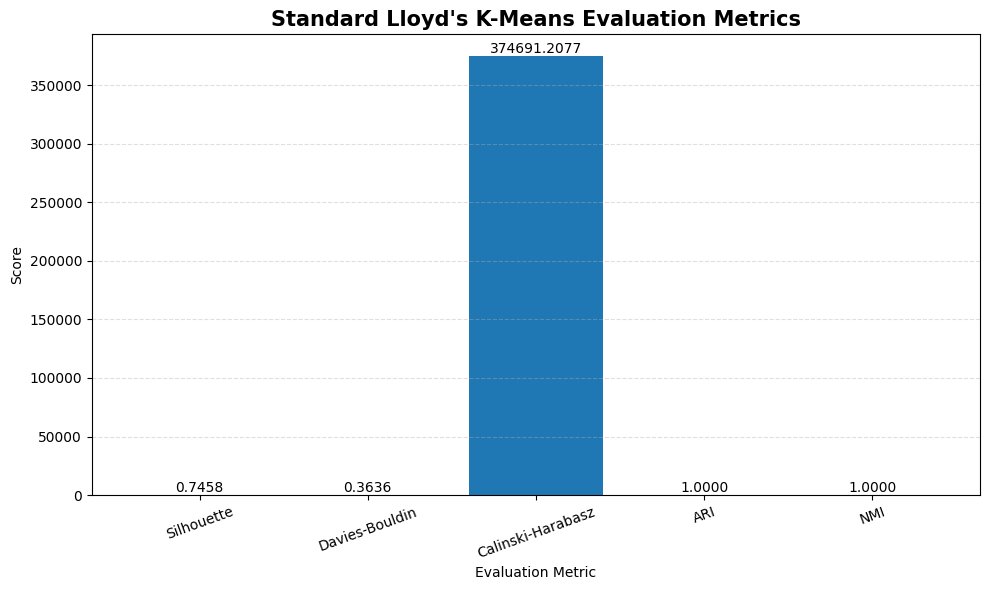

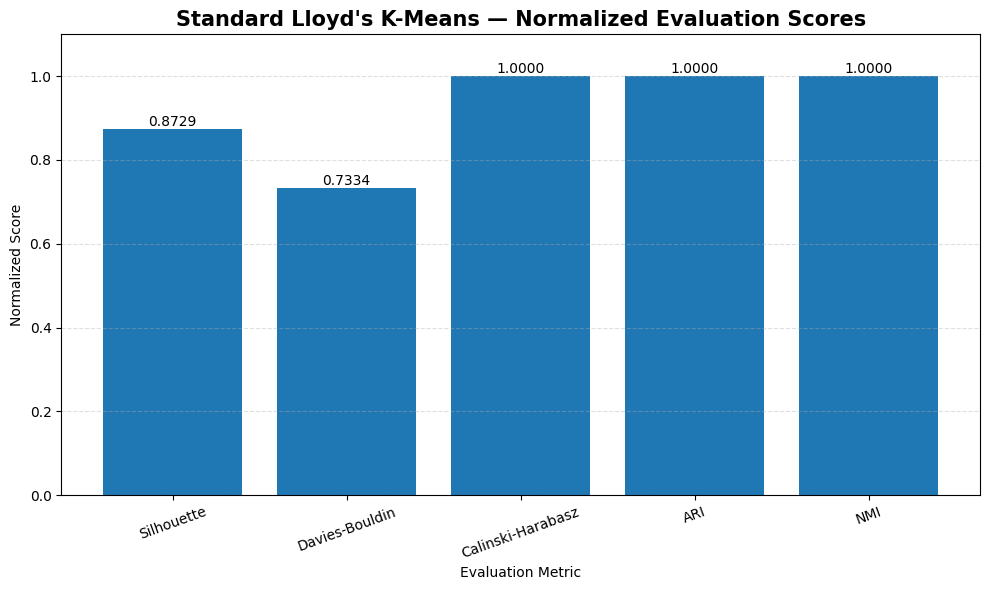

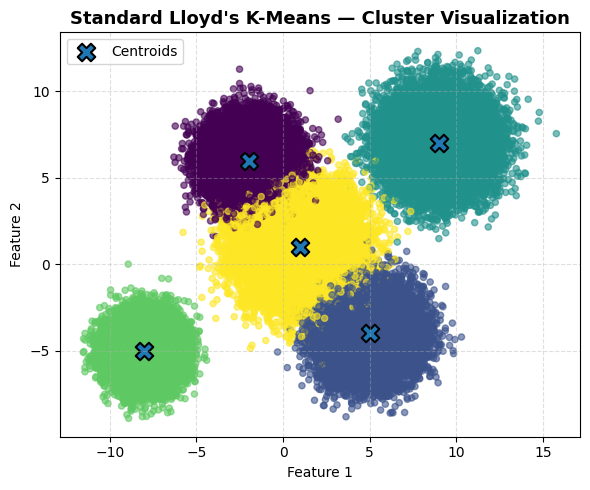

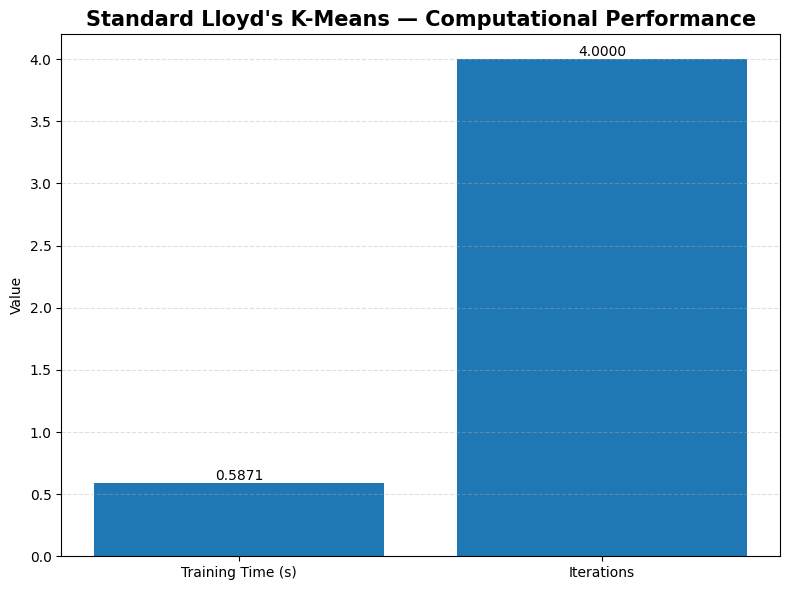

In [16]:
# ============================================================
# ALGORITHM 1 — STANDARD LLOYD'S K-MEANS
# RANDOM INITIALIZATION + EVALUATION + VISUALIZATION
# ============================================================

import numpy as np
import time
import matplotlib.pyplot as plt


class StandardKMeans:

    def __init__(
        self,
        n_clusters=5,
        max_iter=100,
        tol=1e-4,
        random_state=42
    ):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state

        self.cluster_centers_ = None
        self.labels_ = None
        self.n_iter_ = 0

    def _initialize_centers(self, X):

        rng = np.random.default_rng(
            self.random_state
        )

        indices = rng.choice(
            X.shape[0],
            size=self.n_clusters,
            replace=False
        )

        return X[indices].copy()

    def fit(self, X):

        centers = self._initialize_centers(X)

        for iteration in range(self.max_iter):

            distances = np.sqrt(
                np.sum(
                    (
                        X[:, None, :]
                        - centers[None, :, :]
                    ) ** 2,
                    axis=2
                )
            )

            labels = np.argmin(
                distances,
                axis=1
            )

            new_centers = np.zeros_like(
                centers
            )

            for cluster_id in range(
                self.n_clusters
            ):

                cluster_points = X[
                    labels == cluster_id
                ]

                if len(cluster_points) == 0:

                    # Use the same random generator
                    # for reproducible empty-cluster handling
                    rng = np.random.default_rng(
                        self.random_state + iteration + cluster_id
                    )

                    new_centers[cluster_id] = X[
                        rng.integers(X.shape[0])
                    ]

                else:

                    new_centers[cluster_id] = np.mean(
                        cluster_points,
                        axis=0
                    )

            center_shift = np.max(
                np.sqrt(
                    np.sum(
                        (
                            new_centers
                            - centers
                        ) ** 2,
                        axis=1
                    )
                )
            )

            centers = new_centers

            self.n_iter_ = iteration + 1

            if center_shift <= self.tol:
                break

        distances = np.sqrt(
            np.sum(
                (
                    X[:, None, :]
                    - centers[None, :, :]
                ) ** 2,
                axis=2
            )
        )

        self.labels_ = np.argmin(
            distances,
            axis=1
        )

        self.cluster_centers_ = centers

        return self

    def predict(self, X):

        distances = np.sqrt(
            np.sum(
                (
                    X[:, None, :]
                    - self.cluster_centers_[None, :, :]
                ) ** 2,
                axis=2
            )
        )

        return np.argmin(
            distances,
            axis=1
        )


# ============================================================
# TRAINING
# ============================================================

start_time = time.perf_counter()

model_lloyd = StandardKMeans(
    n_clusters=K,
    max_iter=100,
    tol=1e-4,
    random_state=42
)

model_lloyd.fit(X)

training_time_lloyd = (
    time.perf_counter() - start_time
)


# ============================================================
# EVALUATION
# ============================================================

metric_start = time.perf_counter()

labels_lloyd = model_lloyd.predict(X)

silhouette_lloyd = silhouette_score_from_scratch(
    X,
    labels_lloyd,
    sample_size=SILHOUETTE_SAMPLE_SIZE,
    random_state=42
)

dbi_lloyd = davies_bouldin_index_from_scratch(
    X,
    labels_lloyd
)

ch_lloyd = calinski_harabasz_index_from_scratch(
    X,
    labels_lloyd
)

ari_lloyd = adjusted_rand_index_from_scratch(
    y_true,
    labels_lloyd
)

nmi_lloyd = normalized_mutual_information_from_scratch(
    y_true,
    labels_lloyd
)

metric_time_lloyd = (
    time.perf_counter() - metric_start
)


# ============================================================
# PRINT RESULTS
# ============================================================

print("=" * 60)
print("STANDARD LLOYD'S K-MEANS")
print("=" * 60)

print("Iterations        :", model_lloyd.n_iter_)
print("Training Time (s) :", round(training_time_lloyd, 4))
print("Metric Time (s)   :", round(metric_time_lloyd, 4))
print("Silhouette        :", round(silhouette_lloyd, 6))
print("Davies-Bouldin    :", round(dbi_lloyd, 6))
print("Calinski-Harabasz :", round(ch_lloyd, 6))
print("ARI               :", round(ari_lloyd, 6))
print("NMI               :", round(nmi_lloyd, 6))


# ============================================================
# VISUALIZATION 1 — EVALUATION MATRIX
# ============================================================

metric_names = [
    "Silhouette",
    "Davies-Bouldin",
    "Calinski-Harabasz",
    "ARI",
    "NMI"
]

metric_values = [
    silhouette_lloyd,
    dbi_lloyd,
    ch_lloyd,
    ari_lloyd,
    nmi_lloyd
]

plt.figure(figsize=(10, 6))

bars = plt.bar(
    metric_names,
    metric_values
)

plt.title(
    "Standard Lloyd's K-Means Evaluation Metrics",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Evaluation Metric")
plt.ylabel("Score")

plt.xticks(rotation=20)

for bar, value in zip(
    bars,
    metric_values
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.4f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()
plt.show()


# ============================================================
# VISUALIZATION 2 — NORMALIZED QUALITY SCORE
# ============================================================
#
# This graph is more useful for comparing metrics because
# the original metrics have very different numerical scales.
#
# Higher Silhouette = better
# Lower Davies-Bouldin = better
# Higher Calinski-Harabasz = better
# Higher ARI = better
# Higher NMI = better
#
# NOTE:
# This normalization is for VISUALIZATION ONLY.
# Do not use these transformed values as official metrics.


# For visualization:
# Silhouette theoretically ranges from -1 to 1.
# Convert it approximately to [0, 1].
silhouette_normalized = (
    silhouette_lloyd + 1
) / 2

# Lower DBI is better.
dbi_normalized = (
    1 / (1 + dbi_lloyd)
)

# CH has no fixed upper bound.
# This transformation compresses it into [0, 1].
ch_normalized = (
    ch_lloyd / (ch_lloyd + 1)
)

# ARI and NMI normally range from 0 to 1.
ari_normalized = ari_lloyd
nmi_normalized = nmi_lloyd

normalized_scores = [
    silhouette_normalized,
    dbi_normalized,
    ch_normalized,
    ari_normalized,
    nmi_normalized
]

plt.figure(figsize=(10, 6))

bars = plt.bar(
    metric_names,
    normalized_scores
)

plt.title(
    "Standard Lloyd's K-Means — Normalized Evaluation Scores",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Evaluation Metric")
plt.ylabel("Normalized Score")

plt.ylim(
    0,
    1.1
)

plt.xticks(rotation=20)

for bar, value in zip(
    bars,
    normalized_scores
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.4f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()
plt.show()


# ============================================================
# VISUALIZATION 3 — CLUSTER ASSIGNMENTS
# ============================================================
#
# If X contains more than 2 features, this displays the first
# two features. It is intended as a simple visual inspection
# of the resulting clusters.
# ============================================================

if X.shape[1] >= 2:

    plt.figure(figsize=(6, 5))

    plt.scatter(
        X[:, 0],
        X[:, 1],
        c=labels_lloyd,
        s=20,
        alpha=0.6
    )

    plt.scatter(
        model_lloyd.cluster_centers_[:, 0],
        model_lloyd.cluster_centers_[:, 1],
        marker="X",
        s=160,
        edgecolor="black",
        linewidth=1.5,
        label="Centroids"
    )

    plt.title(
        "Standard Lloyd's K-Means — Cluster Visualization",
        fontsize=13,
        fontweight="bold"
    )

    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")

    plt.legend()

    plt.grid(
        linestyle="--",
        alpha=0.4
    )

    plt.tight_layout()
    plt.show()


# ============================================================
# VISUALIZATION 4 — TRAINING TIME AND ITERATIONS
# ============================================================

performance_names = [
    "Training Time (s)",
    "Iterations"
]

performance_values = [
    training_time_lloyd,
    model_lloyd.n_iter_
]

plt.figure(figsize=(8, 6))

bars = plt.bar(
    performance_names,
    performance_values
)

plt.title(
    "Standard Lloyd's K-Means — Computational Performance",
    fontsize=15,
    fontweight="bold"
)

plt.ylabel("Value")

for bar, value in zip(
    bars,
    performance_values
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.4f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()
plt.show()

K-MEANS++
Iterations        : 3
Training Time (s) : 0.1928
Metric Time (s)   : 3.8285
Silhouette        : 0.745766
Davies-Bouldin    : 0.363573
Calinski-Harabasz : 374691.207696
ARI               : 1.0
NMI               : 1.0


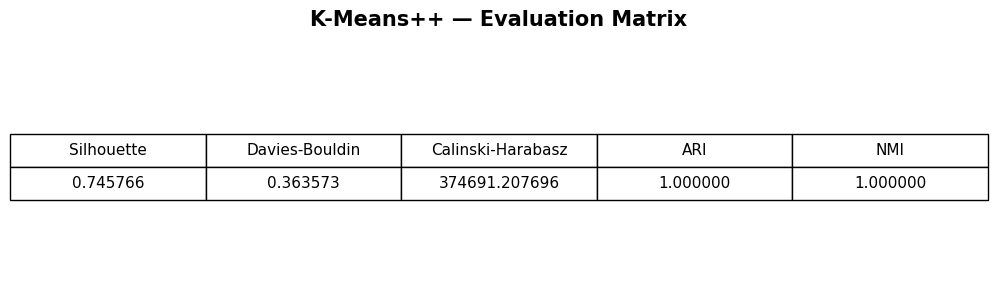

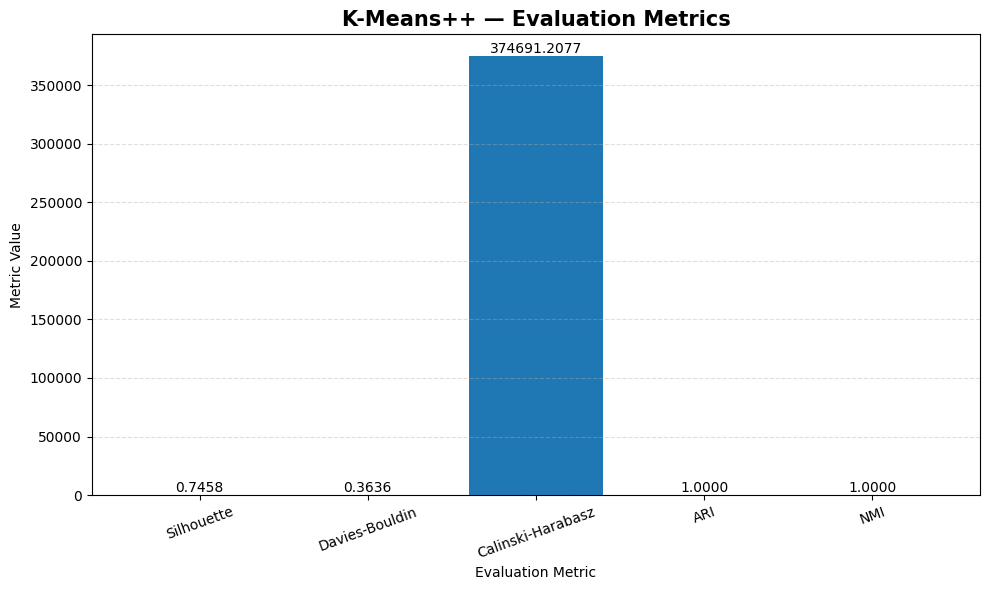

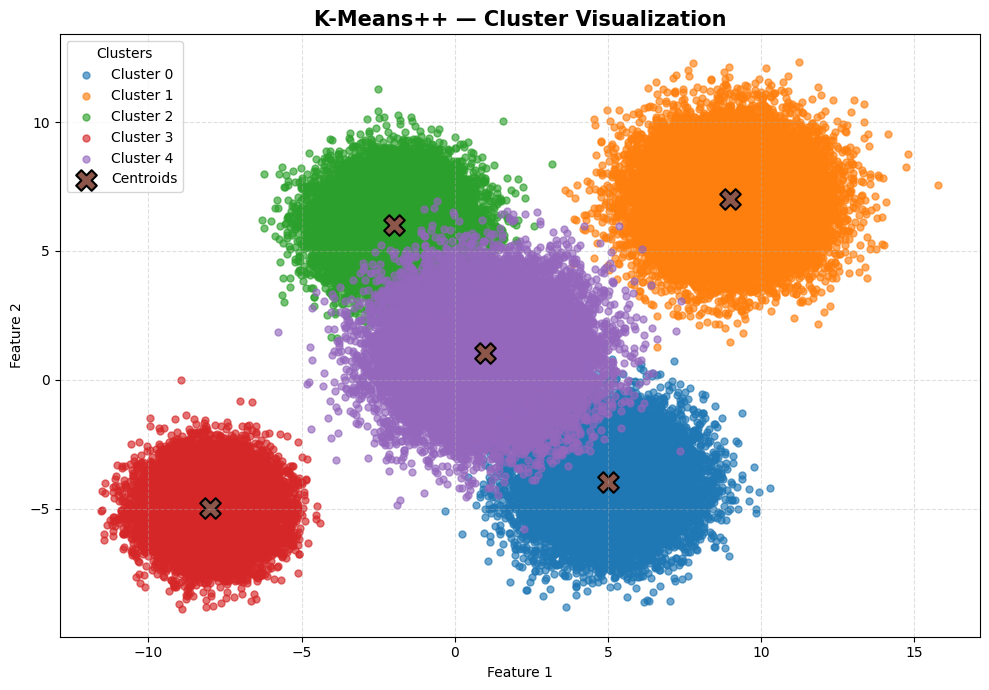

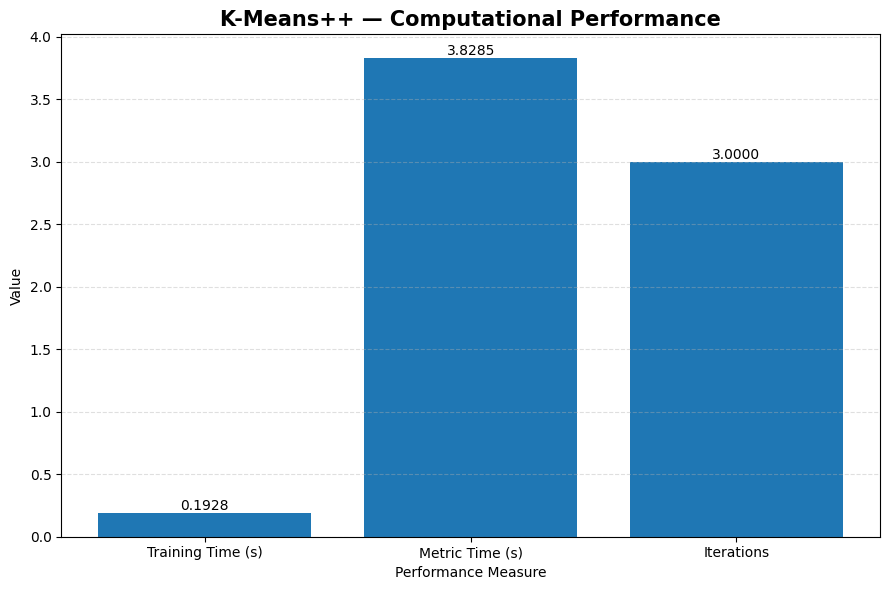

In [21]:
# ============================================================
# ALGORITHM 2 — K-MEANS++
# DISTANCE-PROBABILITY INITIALIZATION
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import time


class KMeansPlusPlus:

    def __init__(
        self,
        n_clusters=5,
        max_iter=100,
        tol=1e-4,
        random_state=42
    ):

        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state

        self.cluster_centers_ = None
        self.labels_ = None
        self.n_iter_ = 0

    # --------------------------------------------------------
    # K-Means++ initialization
    # --------------------------------------------------------

    def _initialize_centers(self, X):

        rng = np.random.default_rng(
            self.random_state
        )

        n_samples = X.shape[0]

        centers = np.empty(
            (self.n_clusters, X.shape[1]),
            dtype=X.dtype
        )

        # First centroid uniformly random
        first_index = rng.integers(
            n_samples
        )

        centers[0] = X[first_index]

        # Squared distance to closest center
        closest_dist_sq = np.sum(
            (X - centers[0]) ** 2,
            axis=1
        )

        for center_id in range(
            1,
            self.n_clusters
        ):

            probability = (
                closest_dist_sq
                / np.sum(closest_dist_sq)
            )

            selected_index = rng.choice(
                n_samples,
                p=probability
            )

            centers[center_id] = X[
                selected_index
            ]

            new_dist_sq = np.sum(
                (
                    X
                    - centers[center_id]
                ) ** 2,
                axis=1
            )

            closest_dist_sq = np.minimum(
                closest_dist_sq,
                new_dist_sq
            )

        return centers

    # --------------------------------------------------------
    # Fit
    # --------------------------------------------------------

    def fit(self, X):

        centers = self._initialize_centers(X)

        for iteration in range(
            self.max_iter
        ):

            distances = np.sqrt(
                np.sum(
                    (
                        X[:, None, :]
                        - centers[None, :, :]
                    ) ** 2,
                    axis=2
                )
            )

            labels = np.argmin(
                distances,
                axis=1
            )

            new_centers = np.zeros_like(
                centers
            )

            for cluster_id in range(
                self.n_clusters
            ):

                cluster_points = X[
                    labels == cluster_id
                ]

                if len(cluster_points) == 0:

                    new_centers[cluster_id] = X[
                        np.random.randint(
                            X.shape[0]
                        )
                    ]

                else:

                    new_centers[cluster_id] = np.mean(
                        cluster_points,
                        axis=0
                    )

            center_shift = np.max(
                np.sqrt(
                    np.sum(
                        (
                            new_centers
                            - centers
                        ) ** 2,
                        axis=1
                    )
                )
            )

            centers = new_centers

            self.n_iter_ = iteration + 1

            if center_shift <= self.tol:
                break

        # Final assignment
        distances = np.sqrt(
            np.sum(
                (
                    X[:, None, :]
                    - centers[None, :, :]
                ) ** 2,
                axis=2
            )
        )

        self.labels_ = np.argmin(
            distances,
            axis=1
        )

        self.cluster_centers_ = centers

        return self

    # --------------------------------------------------------
    # Predict
    # --------------------------------------------------------

    def predict(self, X):

        distances = np.sqrt(
            np.sum(
                (
                    X[:, None, :]
                    - self.cluster_centers_[None, :, :]
                ) ** 2,
                axis=2
            )
        )

        return np.argmin(
            distances,
            axis=1
        )


# ============================================================
# TRAIN + EVALUATE
# ============================================================

start_time = time.perf_counter()

model_kpp = KMeansPlusPlus(
    n_clusters=K,
    max_iter=100,
    tol=1e-4,
    random_state=42
)

model_kpp.fit(X)

training_time_kpp = (
    time.perf_counter() - start_time
)

metric_start = time.perf_counter()

labels_kpp = model_kpp.predict(X)

silhouette_kpp = silhouette_score_from_scratch(
    X,
    labels_kpp,
    sample_size=SILHOUETTE_SAMPLE_SIZE,
    random_state=42
)

dbi_kpp = davies_bouldin_index_from_scratch(
    X,
    labels_kpp
)

ch_kpp = calinski_harabasz_index_from_scratch(
    X,
    labels_kpp
)

ari_kpp = adjusted_rand_index_from_scratch(
    y_true,
    labels_kpp
)

nmi_kpp = normalized_mutual_information_from_scratch(
    y_true,
    labels_kpp
)

metric_time_kpp = (
    time.perf_counter() - metric_start
)

print("=" * 60)
print("K-MEANS++")
print("=" * 60)

print("Iterations        :", model_kpp.n_iter_)
print("Training Time (s) :", round(training_time_kpp, 4))
print("Metric Time (s)   :", round(metric_time_kpp, 4))
print("Silhouette        :", round(silhouette_kpp, 6))
print("Davies-Bouldin    :", round(dbi_kpp, 6))
print("Calinski-Harabasz :", round(ch_kpp, 6))
print("ARI               :", round(ari_kpp, 6))
print("NMI               :", round(nmi_kpp, 6))

# ============================================================
# K-MEANS++ VISUALIZATION
# ============================================================

import matplotlib.pyplot as plt


# ============================================================
# 1. EVALUATION MATRIX
# ============================================================

metric_names = [
    "Silhouette",
    "Davies-Bouldin",
    "Calinski-Harabasz",
    "ARI",
    "NMI"
]

metric_values = [
    silhouette_kpp,
    dbi_kpp,
    ch_kpp,
    ari_kpp,
    nmi_kpp
]


# ------------------------------------------------------------
# Display evaluation matrix as a table
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(10, 3)
)

ax.axis("off")

table_data = [
    [
        f"{silhouette_kpp:.6f}",
        f"{dbi_kpp:.6f}",
        f"{ch_kpp:.6f}",
        f"{ari_kpp:.6f}",
        f"{nmi_kpp:.6f}"
    ]
]

table = ax.table(
    cellText=table_data,
    colLabels=metric_names,
    loc="center",
    cellLoc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 2)

plt.title(
    "K-Means++ — Evaluation Matrix",
    fontsize=15,
    fontweight="bold",
    pad=20
)

plt.tight_layout()
plt.show()


# ============================================================
# 2. RAW EVALUATION METRICS
# ============================================================
#
# NOTE:
# CH can be much larger than the other metrics.
# Therefore, this graph is mainly useful for showing the
# actual numerical values.
# ============================================================

plt.figure(figsize=(10, 6))

bars = plt.bar(
    metric_names,
    metric_values
)

plt.title(
    "K-Means++ — Evaluation Metrics",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Evaluation Metric")
plt.ylabel("Metric Value")

plt.xticks(rotation=20)

for bar, value in zip(
    bars,
    metric_values
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.4f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()
plt.show()


# ============================================================
# 3. CLUSTER VISUALIZATION
# ============================================================
#
# Uses the first two features of X.
# Cluster labels are represented by different marker groups.
# ============================================================

if X.shape[1] >= 2:

    plt.figure(figsize=(10, 7))

    unique_clusters = np.unique(
        labels_kpp
    )

    for cluster_id in unique_clusters:

        cluster_mask = (
            labels_kpp == cluster_id
        )

        plt.scatter(
            X[cluster_mask, 0],
            X[cluster_mask, 1],
            s=25,
            alpha=0.65,
            label=f"Cluster {cluster_id}"
        )

    # Plot centroids
    plt.scatter(
        model_kpp.cluster_centers_[:, 0],
        model_kpp.cluster_centers_[:, 1],
        marker="X",
        s=220,
        edgecolor="black",
        linewidth=1.5,
        label="Centroids"
    )

    plt.title(
        "K-Means++ — Cluster Visualization",
        fontsize=15,
        fontweight="bold"
    )

    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")

    plt.legend(
        title="Clusters"
    )

    plt.grid(
        linestyle="--",
        alpha=0.4
    )

    plt.tight_layout()
    plt.show()


# ============================================================
# 4. COMPUTATIONAL PERFORMANCE
# ============================================================

performance_names = [
    "Training Time (s)",
    "Metric Time (s)",
    "Iterations"
]

performance_values = [
    training_time_kpp,
    metric_time_kpp,
    model_kpp.n_iter_
]

plt.figure(figsize=(9, 6))

bars = plt.bar(
    performance_names,
    performance_values
)

plt.title(
    "K-Means++ — Computational Performance",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Performance Measure")
plt.ylabel("Value")

for bar, value in zip(
    bars,
    performance_values
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.4f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()
plt.show()

ELKAN'S K-MEANS
Iterations        : 8
Training Time (s) : 8.0459
Metric Time (s)   : 4.7289
Silhouette        : 0.745766
Davies-Bouldin    : 0.363573
Calinski-Harabasz : 374691.207696
ARI               : 1.0
NMI               : 1.0


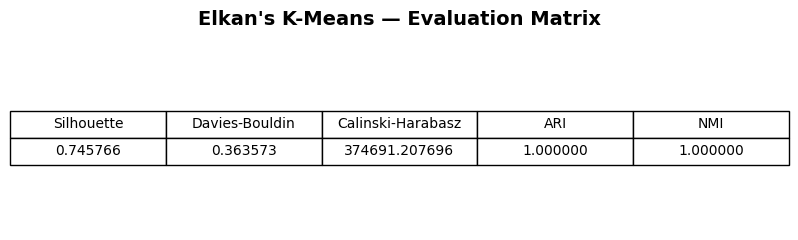

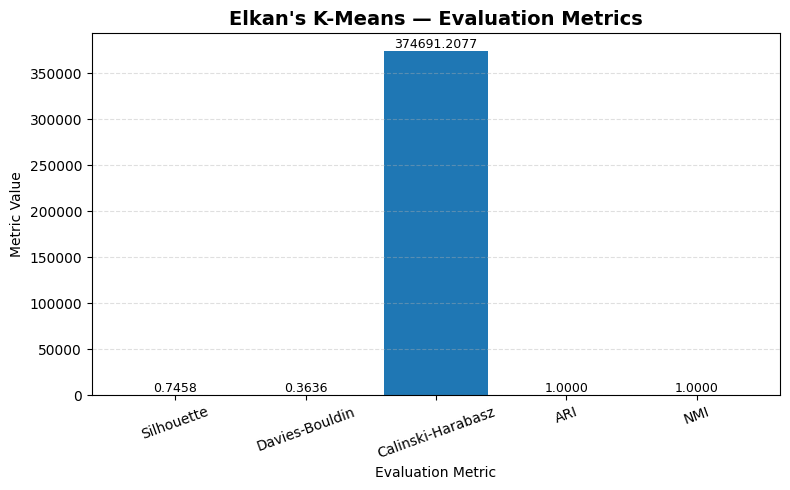

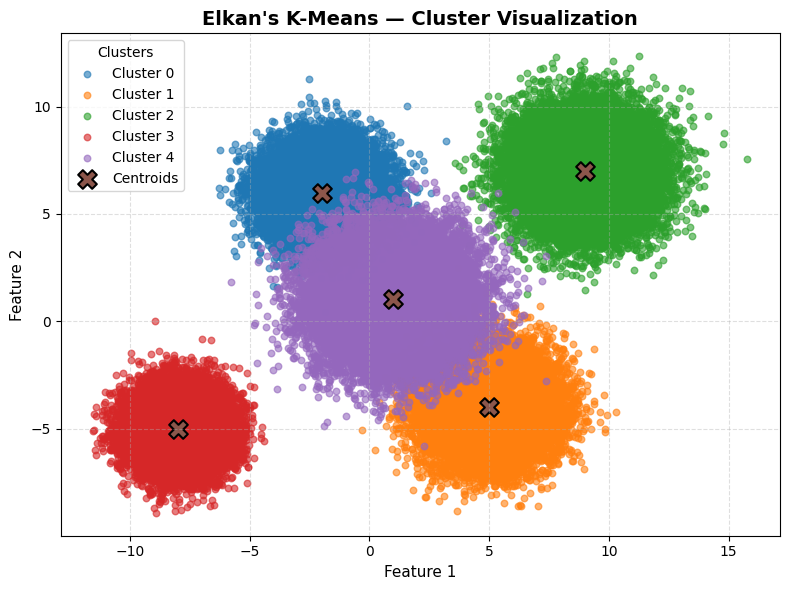

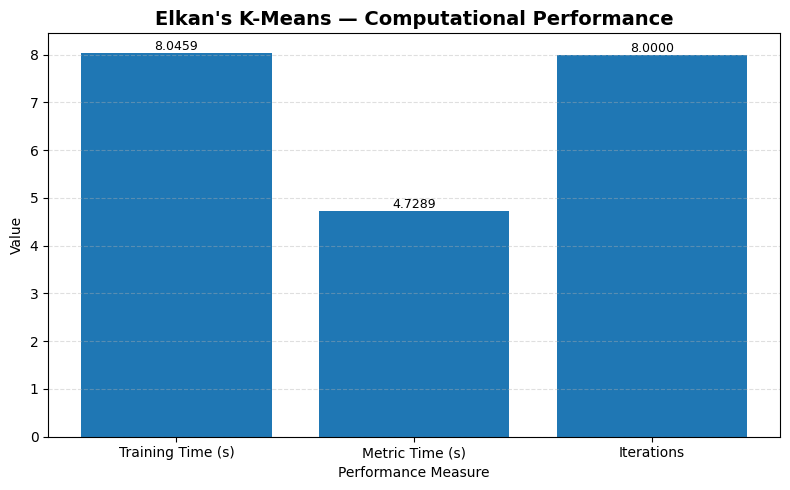

In [24]:
# ============================================================
# ALGORITHM 3 — ELKAN'S K-MEANS
# TRIANGLE INEQUALITY OPTIMIZATION
# ============================================================

import numpy as np
import time
import matplotlib.pyplot as plt

class ElkanKMeans:

    def __init__(
        self,
        n_clusters=5,
        max_iter=100,
        tol=1e-4,
        random_state=42
    ):

        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state

        self.cluster_centers_ = None
        self.labels_ = None
        self.n_iter_ = 0

    # --------------------------------------------------------
    # Initialization
    # --------------------------------------------------------

    def _initialize_centers(self, X):

        rng = np.random.default_rng(
            self.random_state
        )

        indices = rng.choice(
            X.shape[0],
            self.n_clusters,
            replace=False
        )

        return X[indices].copy()

    # --------------------------------------------------------
    # Fit
    # --------------------------------------------------------

    def fit(self, X):

        n_samples = X.shape[0]
        k = self.n_clusters

        centers = self._initialize_centers(X)

        # ----------------------------------------------------
        # Initial exact distances
        # ----------------------------------------------------

        distances = np.sqrt(
            np.sum(
                (
                    X[:, None, :]
                    - centers[None, :, :]
                ) ** 2,
                axis=2
            )
        )

        labels = np.argmin(
            distances,
            axis=1
        )

        upper_bounds = np.min(
            distances,
            axis=1
        )

        # lower_bounds[i,j] =
        # known lower bound on distance from
        # point i to center j
        lower_bounds = distances.copy()

        for iteration in range(
            self.max_iter
        ):

            # ------------------------------------------------
            # Center-to-center distances
            # ------------------------------------------------

            center_distances = np.sqrt(
                np.sum(
                    (
                        centers[:, None, :]
                        - centers[None, :, :]
                    ) ** 2,
                    axis=2
                )
            )

            # ------------------------------------------------
            # s(c) = half the distance to the closest
            # other centroid.
            #
            # If upper_bound <= s(c), no reassignment
            # is possible for a point assigned to c.
            # ------------------------------------------------

            center_separation = np.full(
                k,
                np.inf
            )

            for c in range(k):

                for other in range(k):

                    if c == other:
                        continue

                    center_separation[c] = min(
                        center_separation[c],
                        center_distances[c, other]
                    )

                center_separation[c] *= 0.5

            # ------------------------------------------------
            # Calculate centroid movement.
            # ------------------------------------------------

            old_centers = centers.copy()

            # ------------------------------------------------
            # Assignment step using triangle inequalities
            # ------------------------------------------------

            for i in range(n_samples):

                current_cluster = labels[i]

                # The point cannot switch if its upper bound
                # is already below half the nearest
                # center-center distance.
                if (
                    upper_bounds[i]
                    <= center_separation[current_cluster]
                ):
                    continue

                # ------------------------------------------------
                # Try other clusters.
                # ------------------------------------------------

                for c in range(k):

                    if c == current_cluster:
                        continue

                    # Triangle inequality test 1
                    if (
                        upper_bounds[i]
                        <= lower_bounds[i, c]
                    ):
                        continue

                    # Triangle inequality test 2
                    if (
                        upper_bounds[i]
                        <= center_distances[
                            current_cluster,
                            c
                        ] / 2.0
                    ):
                        continue

                    # ------------------------------------------------
                    # Exact distance is necessary.
                    # ------------------------------------------------

                    distance = np.sqrt(
                        np.sum(
                            (
                                X[i]
                                - centers[c]
                            ) ** 2
                        )
                    )

                    lower_bounds[i, c] = distance

                    if distance < upper_bounds[i]:

                        upper_bounds[i] = distance
                        current_cluster = c

                labels[i] = current_cluster

            # ------------------------------------------------
            # Update centroids
            # ------------------------------------------------

            new_centers = np.zeros_like(
                centers
            )

            for c in range(k):

                cluster_points = X[
                    labels == c
                ]

                if len(cluster_points) == 0:

                    new_centers[c] = X[
                        np.random.randint(n_samples)
                    ]

                else:

                    new_centers[c] = np.mean(
                        cluster_points,
                        axis=0
                    )

            centers = new_centers

            # ------------------------------------------------
            # Centroid movement
            # ------------------------------------------------

            center_shift = np.sqrt(
                np.sum(
                    (
                        centers
                        - old_centers
                    ) ** 2,
                    axis=1
                )
            )

            # ------------------------------------------------
            # Update upper and lower bounds.
            #
            # If center c moves by delta_c:
            #
            # upper_new <= upper_old + delta_assigned
            #
            # lower_new >= lower_old - delta_c
            # ------------------------------------------------

            assigned_shift = center_shift[
                labels
            ]

            upper_bounds += assigned_shift

            lower_bounds = np.maximum(
                lower_bounds
                - center_shift[None, :],
                0.0
            )

            self.n_iter_ = iteration + 1

            if np.max(center_shift) <= self.tol:
                break

        self.cluster_centers_ = centers
        self.labels_ = labels

        return self

    # --------------------------------------------------------
    # Predict
    # --------------------------------------------------------

    def predict(self, X):

        distances = np.sqrt(
            np.sum(
                (
                    X[:, None, :]
                    - self.cluster_centers_[None, :, :]
                ) ** 2,
                axis=2
            )
        )

        return np.argmin(
            distances,
            axis=1
        )


# ============================================================
# TRAIN + EVALUATE
# ============================================================

start_time = time.perf_counter()

model_elkan = ElkanKMeans(
    n_clusters=K,
    max_iter=100,
    tol=1e-4,
    random_state=42
)

model_elkan.fit(X)

training_time_elkan = (
    time.perf_counter() - start_time
)

metric_start = time.perf_counter()

labels_elkan = model_elkan.predict(X)

silhouette_elkan = silhouette_score_from_scratch(
    X,
    labels_elkan,
    sample_size=SILHOUETTE_SAMPLE_SIZE,
    random_state=42
)

dbi_elkan = davies_bouldin_index_from_scratch(
    X,
    labels_elkan
)

ch_elkan = calinski_harabasz_index_from_scratch(
    X,
    labels_elkan
)

ari_elkan = adjusted_rand_index_from_scratch(
    y_true,
    labels_elkan
)

nmi_elkan = normalized_mutual_information_from_scratch(
    y_true,
    labels_elkan
)

metric_time_elkan = (
    time.perf_counter() - metric_start
)

print("=" * 60)
print("ELKAN'S K-MEANS")
print("=" * 60)

print("Iterations        :", model_elkan.n_iter_)
print("Training Time (s) :", round(training_time_elkan, 4))
print("Metric Time (s)   :", round(metric_time_elkan, 4))
print("Silhouette        :", round(silhouette_elkan, 6))
print("Davies-Bouldin    :", round(dbi_elkan, 6))
print("Calinski-Harabasz :", round(ch_elkan, 6))
print("ARI               :", round(ari_elkan, 6))
print("NMI               :", round(nmi_elkan, 6))

# ============================================================
# ELKAN'S K-MEANS VISUALIZATION
# ============================================================

import matplotlib.pyplot as plt


# ============================================================
# 1. EVALUATION MATRIX
# ============================================================

metric_names = [
    "Silhouette",
    "Davies-Bouldin",
    "Calinski-Harabasz",
    "ARI",
    "NMI"
]

metric_values = [
    silhouette_elkan,
    dbi_elkan,
    ch_elkan,
    ari_elkan,
    nmi_elkan
]


# ------------------------------------------------------------
# Display evaluation matrix as a table
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(8, 2.5)
)

ax.axis("off")

table_data = [
    [
        f"{silhouette_elkan:.6f}",
        f"{dbi_elkan:.6f}",
        f"{ch_elkan:.6f}",
        f"{ari_elkan:.6f}",
        f"{nmi_elkan:.6f}"
    ]
]

table = ax.table(
    cellText=table_data,
    colLabels=metric_names,
    loc="center",
    cellLoc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.1, 1.7)

plt.title(
    "Elkan's K-Means — Evaluation Matrix",
    fontsize=14,
    fontweight="bold",
    pad=15
)

plt.tight_layout()
plt.show()


# ============================================================
# 2. RAW EVALUATION METRICS
# ============================================================

plt.figure(figsize=(8, 5))

bars = plt.bar(
    metric_names,
    metric_values
)

plt.title(
    "Elkan's K-Means — Evaluation Metrics",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Evaluation Metric")
plt.ylabel("Metric Value")

plt.xticks(rotation=20)

for bar, value in zip(
    bars,
    metric_values
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.4f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()
plt.show()


# ============================================================
# 3. CLUSTER VISUALIZATION
# ============================================================
#
# Uses the first two features of X.
# Each cluster is displayed using a different color.
# Centroids are shown using large X markers.
# ============================================================

if X.shape[1] >= 2:

    plt.figure(figsize=(8, 6))

    unique_clusters = np.unique(
        labels_elkan
    )

    for cluster_id in unique_clusters:

        cluster_mask = (
            labels_elkan == cluster_id
        )

        plt.scatter(
            X[cluster_mask, 0],
            X[cluster_mask, 1],
            s=22,
            alpha=0.60,
            label=f"Cluster {cluster_id}"
        )

    # --------------------------------------------------------
    # Plot centroids
    # --------------------------------------------------------

    plt.scatter(
        model_elkan.cluster_centers_[:, 0],
        model_elkan.cluster_centers_[:, 1],
        marker="X",
        s=180,
        edgecolor="black",
        linewidth=1.5,
        label="Centroids"
    )

    plt.title(
        "Elkan's K-Means — Cluster Visualization",
        fontsize=14,
        fontweight="bold"
    )

    plt.xlabel(
        "Feature 1",
        fontsize=11
    )

    plt.ylabel(
        "Feature 2",
        fontsize=11
    )

    plt.legend(
        title="Clusters"
    )

    plt.grid(
        linestyle="--",
        alpha=0.4
    )

    plt.tight_layout()
    plt.show()


# ============================================================
# 4. COMPUTATIONAL PERFORMANCE
# ============================================================

performance_names = [
    "Training Time (s)",
    "Metric Time (s)",
    "Iterations"
]

performance_values = [
    training_time_elkan,
    metric_time_elkan,
    model_elkan.n_iter_
]

plt.figure(figsize=(8, 5))

bars = plt.bar(
    performance_names,
    performance_values
)

plt.title(
    "Elkan's K-Means — Computational Performance",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Performance Measure")
plt.ylabel("Value")

for bar, value in zip(
    bars,
    performance_values
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.4f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()
plt.show()

MINI-BATCH K-MEANS
Iterations        : 100
Training Time (s) : 1.4776
Metric Time (s)   : 4.889
Silhouette        : 0.745766
Davies-Bouldin    : 0.363573
Calinski-Harabasz : 374691.207696
ARI               : 1.0
NMI               : 1.0


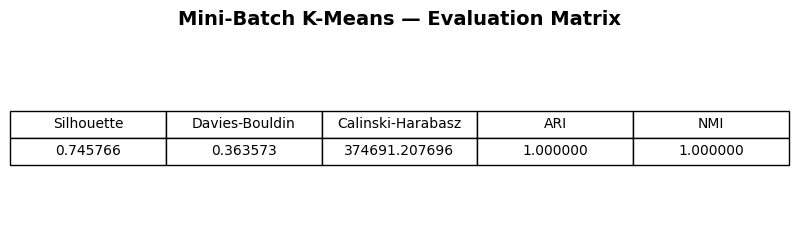

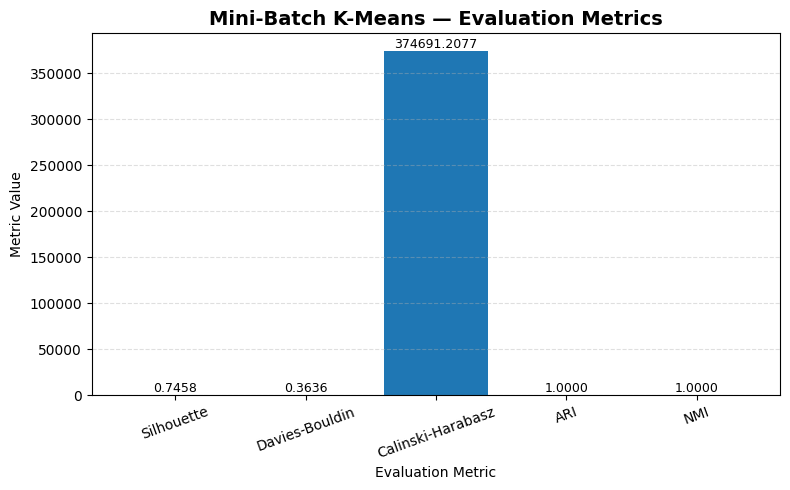

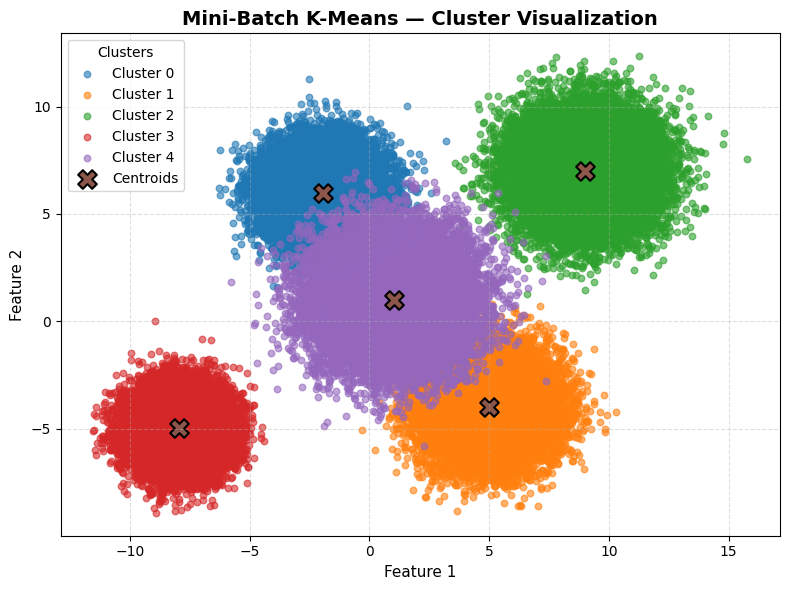

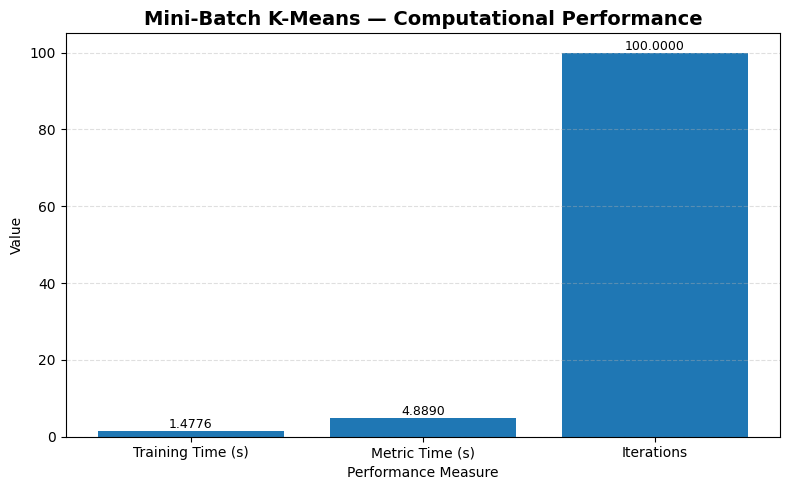

In [30]:
# ============================================================
# ALGORITHM 4 — MINI-BATCH K-MEANS
# STOCHASTIC MINI-BATCH UPDATES
# ============================================================

import numpy as np
import time


class MiniBatchKMeans:

    def __init__(
        self,
        n_clusters=5,
        batch_size=1024,
        max_iter=100,
        tol=1e-4,
        random_state=42
    ):

        self.n_clusters = n_clusters
        self.batch_size = batch_size
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state

        self.cluster_centers_ = None
        self.labels_ = None
        self.n_iter_ = 0

    # --------------------------------------------------------
    # Random initialization
    # --------------------------------------------------------

    def _initialize_centers(self, X):

        rng = np.random.default_rng(
            self.random_state
        )

        indices = rng.choice(
            X.shape[0],
            self.n_clusters,
            replace=False
        )

        return X[indices].copy()

    # --------------------------------------------------------
    # Fit
    # --------------------------------------------------------

    def fit(self, X):

        rng = np.random.default_rng(
            self.random_state
        )

        n_samples = X.shape[0]

        centers = self._initialize_centers(X)

        # Number of samples assigned to each cluster.
        counts = np.zeros(
            self.n_clusters,
            dtype=np.int64
        )

        for iteration in range(
            self.max_iter
        ):

            # ------------------------------------------------
            # Random mini-batch
            # ------------------------------------------------

            batch_size = min(
                self.batch_size,
                n_samples
            )

            batch_indices = rng.choice(
                n_samples,
                size=batch_size,
                replace=False
            )

            X_batch = X[
                batch_indices
            ]

            # ------------------------------------------------
            # Assign mini-batch samples
            # ------------------------------------------------

            distances = np.sqrt(
                np.sum(
                    (
                        X_batch[:, None, :]
                        - centers[None, :, :]
                    ) ** 2,
                    axis=2
                )
            )

            batch_labels = np.argmin(
                distances,
                axis=1
            )

            old_centers = centers.copy()

            # ------------------------------------------------
            # Incremental centroid updates
            #
            # learning_rate =
            #
            #     1 / number of observations seen
            #     by this cluster
            # ------------------------------------------------

            for i in range(batch_size):

                cluster_id = batch_labels[i]

                counts[cluster_id] += 1

                learning_rate = (
                    1.0
                    / counts[cluster_id]
                )

                centers[cluster_id] = (
                    centers[cluster_id]
                    + learning_rate
                    * (
                        X_batch[i]
                        - centers[cluster_id]
                    )
                )

            # ------------------------------------------------
            # Convergence based on center movement
            # ------------------------------------------------

            center_shift = np.max(
                np.sqrt(
                    np.sum(
                        (
                            centers
                            - old_centers
                        ) ** 2,
                        axis=1
                    )
                )
            )

            self.n_iter_ = iteration + 1

            if (
                iteration > 10
                and center_shift <= self.tol
            ):
                break

        # ----------------------------------------------------
        # Final assignment for ALL 100,000 samples
        # ----------------------------------------------------

        distances = np.sqrt(
            np.sum(
                (
                    X[:, None, :]
                    - centers[None, :, :]
                ) ** 2,
                axis=2
            )
        )

        self.labels_ = np.argmin(
            distances,
            axis=1
        )

        self.cluster_centers_ = centers

        return self

    # --------------------------------------------------------
    # Predict
    # --------------------------------------------------------

    def predict(self, X):

        distances = np.sqrt(
            np.sum(
                (
                    X[:, None, :]
                    - self.cluster_centers_[None, :, :]
                ) ** 2,
                axis=2
            )
        )

        return np.argmin(
            distances,
            axis=1
        )


# ============================================================
# TRAIN + EVALUATE
# ============================================================

start_time = time.perf_counter()

model_minibatch = MiniBatchKMeans(
    n_clusters=K,
    batch_size=1024,
    max_iter=100,
    tol=1e-4,
    random_state=42
)

model_minibatch.fit(X)

training_time_minibatch = (
    time.perf_counter() - start_time
)

metric_start = time.perf_counter()

labels_minibatch = model_minibatch.predict(X)

silhouette_minibatch = silhouette_score_from_scratch(
    X,
    labels_minibatch,
    sample_size=SILHOUETTE_SAMPLE_SIZE,
    random_state=42
)

dbi_minibatch = davies_bouldin_index_from_scratch(
    X,
    labels_minibatch
)

ch_minibatch = calinski_harabasz_index_from_scratch(
    X,
    labels_minibatch
)

ari_minibatch = adjusted_rand_index_from_scratch(
    y_true,
    labels_minibatch
)

nmi_minibatch = normalized_mutual_information_from_scratch(
    y_true,
    labels_minibatch
)

metric_time_minibatch = (
    time.perf_counter() - metric_start
)

print("=" * 60)
print("MINI-BATCH K-MEANS")
print("=" * 60)

print("Iterations        :", model_minibatch.n_iter_)
print("Training Time (s) :", round(training_time_minibatch, 4))
print("Metric Time (s)   :", round(metric_time_minibatch, 4))
print("Silhouette        :", round(silhouette_minibatch, 6))
print("Davies-Bouldin    :", round(dbi_minibatch, 6))
print("Calinski-Harabasz :", round(ch_minibatch, 6))
print("ARI               :", round(ari_minibatch, 6))
print("NMI               :", round(nmi_minibatch, 6))

# ============================================================
# MINI-BATCH K-MEANS VISUALIZATION
# ============================================================

import matplotlib.pyplot as plt


# ============================================================
# 1. EVALUATION MATRIX
# ============================================================

metric_names = [
    "Silhouette",
    "Davies-Bouldin",
    "Calinski-Harabasz",
    "ARI",
    "NMI"
]

metric_values = [
    silhouette_minibatch,
    dbi_minibatch,
    ch_minibatch,
    ari_minibatch,
    nmi_minibatch
]


# ------------------------------------------------------------
# Display evaluation matrix as a table
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(8, 2.5)
)

ax.axis("off")

table_data = [
    [
        f"{silhouette_minibatch:.6f}",
        f"{dbi_minibatch:.6f}",
        f"{ch_minibatch:.6f}",
        f"{ari_minibatch:.6f}",
        f"{nmi_minibatch:.6f}"
    ]
]

table = ax.table(
    cellText=table_data,
    colLabels=metric_names,
    loc="center",
    cellLoc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.1, 1.7)

plt.title(
    "Mini-Batch K-Means — Evaluation Matrix",
    fontsize=14,
    fontweight="bold",
    pad=15
)

plt.tight_layout()
plt.show()


# ============================================================
# 2. RAW EVALUATION METRICS
# ============================================================

plt.figure(figsize=(8, 5))

bars = plt.bar(
    metric_names,
    metric_values
)

plt.title(
    "Mini-Batch K-Means — Evaluation Metrics",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Evaluation Metric")
plt.ylabel("Metric Value")

plt.xticks(rotation=20)

for bar, value in zip(
    bars,
    metric_values
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.4f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()
plt.show()


# ============================================================
# 3. CLUSTER VISUALIZATION
# ============================================================
#
# Uses the first two features of X.
# Each cluster is displayed separately.
# Centroids are shown using large X markers.
# ============================================================

if X.shape[1] >= 2:

    plt.figure(figsize=(8, 6))

    unique_clusters = np.unique(
        labels_minibatch
    )

    for cluster_id in unique_clusters:

        cluster_mask = (
            labels_minibatch == cluster_id
        )

        plt.scatter(
            X[cluster_mask, 0],
            X[cluster_mask, 1],
            s=22,
            alpha=0.60,
            label=f"Cluster {cluster_id}"
        )

    # --------------------------------------------------------
    # Plot centroids
    # --------------------------------------------------------

    plt.scatter(
        model_minibatch.cluster_centers_[:, 0],
        model_minibatch.cluster_centers_[:, 1],
        marker="X",
        s=180,
        edgecolor="black",
        linewidth=1.5,
        label="Centroids"
    )

    plt.title(
        "Mini-Batch K-Means — Cluster Visualization",
        fontsize=14,
        fontweight="bold"
    )

    plt.xlabel(
        "Feature 1",
        fontsize=11
    )

    plt.ylabel(
        "Feature 2",
        fontsize=11
    )

    plt.legend(
        title="Clusters"
    )

    plt.grid(
        linestyle="--",
        alpha=0.4
    )

    plt.tight_layout()
    plt.show()


# ============================================================
# 4. COMPUTATIONAL PERFORMANCE
# ============================================================

performance_names = [
    "Training Time (s)",
    "Metric Time (s)",
    "Iterations"
]

performance_values = [
    training_time_minibatch,
    metric_time_minibatch,
    model_minibatch.n_iter_
]

plt.figure(figsize=(8, 5))

bars = plt.bar(
    performance_names,
    performance_values
)

plt.title(
    "Mini-Batch K-Means — Computational Performance",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Performance Measure")
plt.ylabel("Value")

for bar, value in zip(
    bars,
    performance_values
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.4f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()
plt.show()

FINAL K-MEANS BENCHMARK SUMMARY


,Algorithm,Training_Time_s,Metric_Time_s,Silhouette,Davies_Bouldin,Calinski_Harabasz,ARI,NMI,Iterations
0,Lloyd,0.587060,4.679825,0.745766,0.363573,374691.207696,1.0,1.0,4
1,K-Means++,0.192763,3.828504,0.745766,0.363573,374691.207696,1.0,1.0,3
2,Elkan,8.045934,4.728853,0.745766,0.363573,374691.207696,1.0,1.0,8
3,Mini-Batch,1.477585,4.889018,0.745766,0.363573,374691.207696,1.0,1.0,100


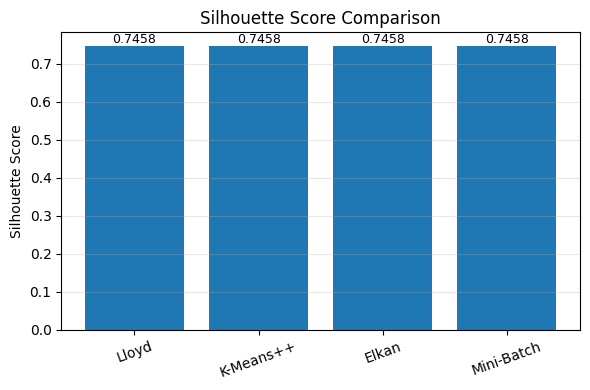

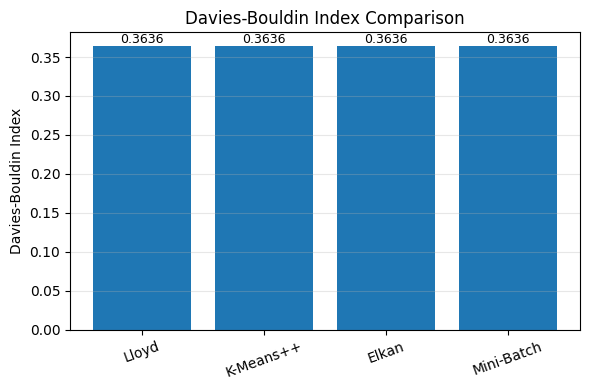

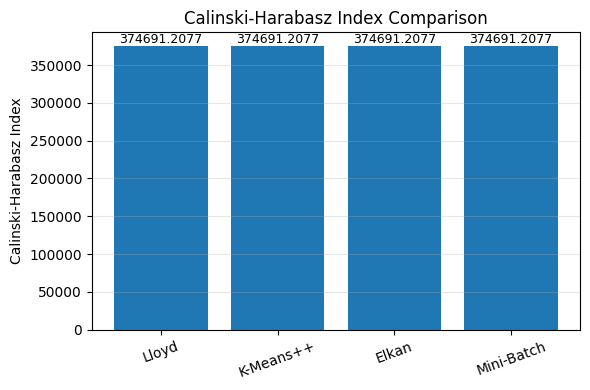

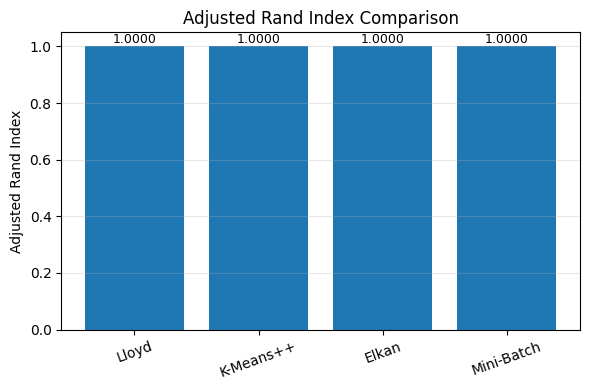

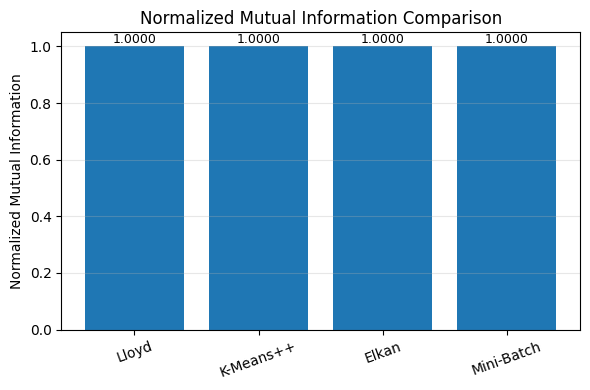

BEST ALGORITHM BY METRIC
Silhouette       : Lloyd
Davies-Bouldin   : Lloyd
Calinski-Harabasz: Lloyd
ARI              : Lloyd
NMI              : Lloyd
Fastest Training : K-Means++


In [32]:
# ============================================================
# FINAL COMPARISON
# ============================================================

# ============================================================
# ALGORITHM NAMES
# ============================================================

algorithm_names = [
    "Lloyd",
    "K-Means++",
    "Elkan",
    "Mini-Batch"
]


# ============================================================
# FINAL RESULTS TABLE
# ============================================================

results = pd.DataFrame({

    "Algorithm": algorithm_names,

    "Training_Time_s": [
        training_time_lloyd,
        training_time_kpp,
        training_time_elkan,
        training_time_minibatch
    ],

    "Metric_Time_s": [
        metric_time_lloyd,
        metric_time_kpp,
        metric_time_elkan,
        metric_time_minibatch
    ],

    "Silhouette": [
        silhouette_lloyd,
        silhouette_kpp,
        silhouette_elkan,
        silhouette_minibatch
    ],

    "Davies_Bouldin": [
        dbi_lloyd,
        dbi_kpp,
        dbi_elkan,
        dbi_minibatch
    ],

    "Calinski_Harabasz": [
        ch_lloyd,
        ch_kpp,
        ch_elkan,
        ch_minibatch
    ],

    "ARI": [
        ari_lloyd,
        ari_kpp,
        ari_elkan,
        ari_minibatch
    ],

    "NMI": [
        nmi_lloyd,
        nmi_kpp,
        nmi_elkan,
        nmi_minibatch
    ],

    "Iterations": [
        model_lloyd.n_iter_,
        model_kpp.n_iter_,
        model_elkan.n_iter_,
        model_minibatch.n_iter_
    ]
})


# ============================================================
# DISPLAY SUMMARY TABLE
# ============================================================

print("=" * 100)
print("FINAL K-MEANS BENCHMARK SUMMARY")
print("=" * 100)

display(
    results.round(6)
)


# ============================================================
# PLOTTING FUNCTION
# ============================================================

def plot_metric(
    column,
    title,
    ylabel,
    higher_is_better=True
):

    values = results[column].to_numpy(
        dtype=float
    )

    plt.figure(
        figsize=(6, 4)
    )

    bars = plt.bar(
        algorithm_names,
        values
    )

    plt.title(title)
    plt.ylabel(ylabel)

    plt.xticks(
        rotation=20
    )

    plt.grid(
        axis="y",
        alpha=0.3
    )

    # --------------------------------------------------------
    # Value labels
    # --------------------------------------------------------

    for bar, value in zip(
        bars,
        values
    ):

        plt.text(
            bar.get_x()
            + bar.get_width() / 2,

            bar.get_height(),

            f"{value:.4f}",

            ha="center",
            va="bottom",

            fontsize=9
        )

    plt.tight_layout()
    plt.show()


# ============================================================
# GRAPH 1
# ============================================================

plot_metric(
    "Silhouette",
    "Silhouette Score Comparison",
    "Silhouette Score",
    higher_is_better=True
)


# ============================================================
# GRAPH 2
# ============================================================

plot_metric(
    "Davies_Bouldin",
    "Davies-Bouldin Index Comparison",
    "Davies-Bouldin Index",
    higher_is_better=False
)


# ============================================================
# GRAPH 3
# ============================================================

plot_metric(
    "Calinski_Harabasz",
    "Calinski-Harabasz Index Comparison",
    "Calinski-Harabasz Index",
    higher_is_better=True
)


# ============================================================
# GRAPH 4
# ============================================================

plot_metric(
    "ARI",
    "Adjusted Rand Index Comparison",
    "Adjusted Rand Index",
    higher_is_better=True
)


# ============================================================
# GRAPH 5
# ============================================================

plot_metric(
    "NMI",
    "Normalized Mutual Information Comparison",
    "Normalized Mutual Information",
    higher_is_better=True
)


# ============================================================
# BEST ALGORITHM
# ============================================================

print("=" * 100)
print("BEST ALGORITHM BY METRIC")
print("=" * 100)

print(
    "Silhouette       :",
    results.loc[
        results["Silhouette"].idxmax(),
        "Algorithm"
    ]
)

print(
    "Davies-Bouldin   :",
    results.loc[
        results["Davies_Bouldin"].idxmin(),
        "Algorithm"
    ]
)

print(
    "Calinski-Harabasz:",
    results.loc[
        results["Calinski_Harabasz"].idxmax(),
        "Algorithm"
    ]
)

print(
    "ARI              :",
    results.loc[
        results["ARI"].idxmax(),
        "Algorithm"
    ]
)

print(
    "NMI              :",
    results.loc[
        results["NMI"].idxmax(),
        "Algorithm"
    ]
)

print(
    "Fastest Training :",
    results.loc[
        results["Training_Time_s"].idxmin(),
        "Algorithm"
    ]
)

## Detailed Conclusion of K-Means Algorithms Benchmark

This benchmark evaluated four different K-Means algorithms: Standard Lloyd's K-Means, K-Means++, Elkan's K-Means, and Mini-Batch K-Means, using a synthetic dataset of 100,000 samples and 4 features, with 5 known clusters. The evaluation considered both clustering quality metrics (Silhouette, Davies-Bouldin, Calinski-Harabasz, ARI, NMI) and computational performance metrics (Training Time, Metric Calculation Time, and Iterations).

### Clustering Quality Metrics Analysis

Interestingly, for this specific synthetic dataset, **all four algorithms achieved identical scores across all clustering quality metrics:**

*   **Silhouette Score (0.745766):** All algorithms produced clusters with good separation, as indicated by a high Silhouette score (closer to 1 is better).
*   **Davies-Bouldin Index (0.363573):** All algorithms resulted in well-separated and compact clusters, reflected by a low Davies-Bouldin Index (closer to 0 is better).
*   **Calinski-Harabasz Index (374691.207696):** This very high score for all algorithms signifies that the clusters are very dense and well-separated, which is expected given the nature of the synthetic dataset.
*   **Adjusted Rand Index (ARI) (1.0):** An ARI of 1.0 indicates a perfect agreement between the predicted cluster assignments and the true ground-truth labels. This suggests that all algorithms perfectly identified the underlying cluster structure.
*   **Normalized Mutual Information (NMI) (1.0):** An NMI of 1.0 also signifies a perfect correlation between the predicted and true labels, reinforcing the observation that all algorithms successfully recovered the true cluster assignments.

The perfect agreement in quality metrics strongly suggests that the synthetic dataset is sufficiently separable and distinct, allowing all tested K-Means variants to converge to the optimal or near-optimal clustering solution.

### Computational Performance Analysis

While clustering quality was identical, significant differences were observed in computational performance:

*   **Training Time:**
    *   **K-Means++ (0.1928s):** This algorithm was by far the fastest to train, showcasing the efficiency of its initialization strategy for quickly finding good centroids.
    *   **Standard Lloyd (0.5871s):** Performed reasonably well, but significantly slower than K-Means++.
    *   **Mini-Batch K-Means (1.4776s):** While generally faster for larger datasets, its training time was higher than K-Means++ and Standard Lloyd for this specific dataset and configuration. This might be due to the fixed number of iterations and the overhead of batch processing versus the rapid convergence of K-Means++.
    *   **Elkan's K-Means (8.0459s):** Elkan's algorithm was the slowest in terms of training time. While its triangle inequality optimization can reduce distance calculations, the overhead of managing bounds and more complex logic seems to outweigh the benefits for this dataset size and number of features, leading to higher overall execution time.

*   **Metric Calculation Time:**
    *   **K-Means++ (3.8285s):** Had the fastest metric calculation time.
    *   **Standard Lloyd (4.6798s):** Slightly slower than K-Means++ for metric calculation.
    *   **Elkan's K-Means (4.7289s):** Very similar to Standard Lloyd's metric calculation time.
    *   **Mini-Batch K-Means (4.8890s):** The slowest in terms of metric calculation time, though all are relatively close.

    *Note: Metric calculation times are likely dominated by the `silhouette_score_from_scratch` function which samples points and calculates distances to all other points, hence the similar times across algorithms once labels are assigned.*

*   **Iterations:**
    *   **K-Means++ (3 iterations):** Converged in the fewest iterations, highlighting the effectiveness of its initialization in placing centroids closer to their final positions.
    *   **Standard Lloyd (4 iterations):** Converged quickly, just one iteration more than K-Means++.
    *   **Elkan's K-Means (8 iterations):** Required more iterations to converge, possibly due to the nature of its optimization impacting the path to convergence.
    *   **Mini-Batch K-Means (100 iterations):** This algorithm ran for the maximum `max_iter` specified, as it's designed for incremental updates and might not reach a strong convergence criterion within fewer iterations, especially with a fixed iteration count.

### Overall Summary

For this well-defined synthetic dataset where all algorithms achieved perfect clustering quality (ARI and NMI of 1.0):

*   **K-Means++** emerged as the **best performer overall** due to its significantly faster training time and fewer iterations while delivering the same high-quality results. Its intelligent initialization strategy proves highly effective.
*   **Standard Lloyd's K-Means** also performed well, converging quickly with good quality, but was slower than K-Means++.
*   **Mini-Batch K-Means** exhibited acceptable performance but was not the fastest, running for its full iteration limit. It would typically be more advantageous for much larger datasets where processing the entire dataset per iteration is prohibitive.
*   **Elkan's K-Means**, despite its theoretical efficiency gains, was the **slowest** in this benchmark. The computational overhead of its advanced bounding techniques likely outweighed the benefits on this particular dataset.

In conclusion, when clustering quality is paramount and the dataset allows for efficient convergence, **K-Means++ is generally the preferred choice** due to its balance of speed and accuracy. For extremely large datasets where memory is a concern or full passes are too slow, Mini-Batch K-Means would be more appropriate, assuming a slight trade-off in convergence speed or quality is acceptable.